In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


os.chdir("../..")
savedir = "data/Heat"

# Tucker ranks (120, 120, 120)

/var/folders/30/0jwhyzsj0rnb88s_49hf9shm0000gq/T/ipykernel_52249/4172527694.py:69: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.16)


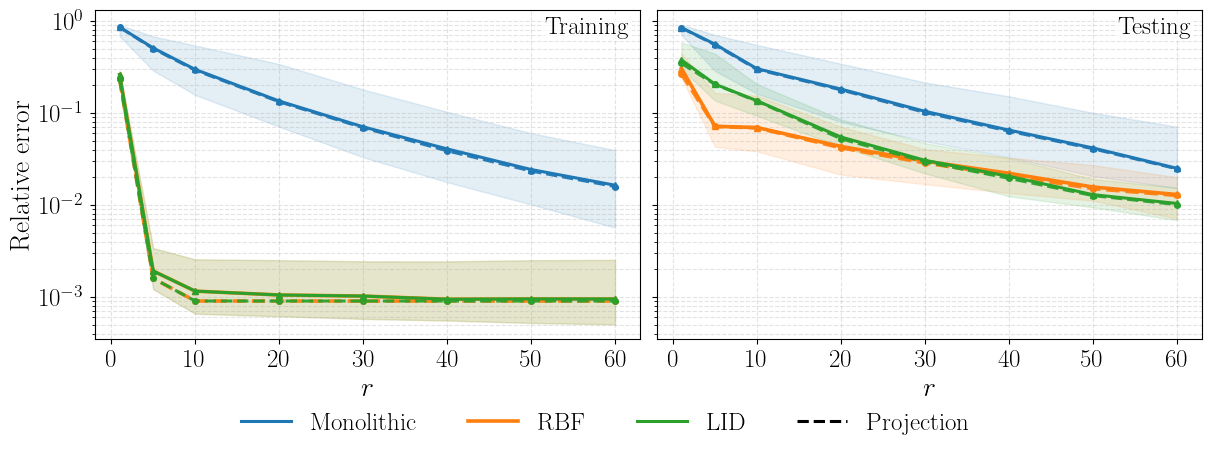

In [8]:


plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
    "font.size": 18,
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

errs = np.load(os.path.join(savedir,"errors_120x120x120.npz"), allow_pickle=True)
r_arr = errs["r_arr"]

methods = ["mono", "rbf", "lid"]
colors = {"mono": "C0", "rbf": "C1", "lid": "C2"}
method_labels = {"mono": r"Monolithic", "rbf": r"RBF", "lid": r"LID"}

base_lw = 2.2
lw_method = {"mono": base_lw, "rbf": base_lw + 0.4, "lid": base_lw}

def plot_subplot(ax, title_text, key_fmt_rom, key_fmt_proj):
    for m in methods:
        # ROM: median + IQR band
        A = errs[key_fmt_rom.format(m=m)]
        med = np.median(A, axis=1)
        lo  = np.quantile(A, 0.25, axis=1)
        hi  = np.quantile(A, 0.75, axis=1)
        ax.plot(r_arr, med, color=colors[m], lw=lw_method[m], marker="^", ms=5)
        ax.fill_between(r_arr, lo, hi, color=colors[m], alpha=0.12)

        # Projection: median only (dashed)
        P = errs[key_fmt_proj.format(m=m)]
        pmed = np.median(P, axis=1)
        ax.plot(r_arr, pmed, color=colors[m], lw=lw_method[m], ls="--", marker="o", ms=4, alpha=0.95)

    ax.set_yscale("log")
    ax.grid(True, which="both", ls="--", alpha=0.35)

    # Title inside (top-right corner)
    ax.text(
        0.98, 0.98, title_text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=18,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2.0),
    )

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True, sharex=True, sharey=True)

plot_subplot(ax[0], r" Training", "{m}_rom_train", "{m}_proj_train")
plot_subplot(ax[1], r" Testing",  "{m}_rom_test",  "{m}_proj_test")


for a in ax:
    a.set_xlabel(r"$r$")

ax[0].set_ylabel(r"Relative error")

method_handles = [
    Line2D([0],[0], color=colors[m], lw=lw_method[m], label=method_labels[m]) for m in methods
]
style_handles = [
    #Line2D([0],[0], color="k", lw=2.2, ls="-",  label=r"ROM error"),
    Line2D([0],[0], color="k", lw=2.2, ls="--", label=r"Projection"),
]

fig.subplots_adjust(bottom=0.16)
fig.legend(method_handles + style_handles,
           [h.get_label() for h in (method_handles + style_handles)],
           loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.13))

plt.show()


# Tucker ranks: (60, 60, 60)

/var/folders/30/0jwhyzsj0rnb88s_49hf9shm0000gq/T/ipykernel_52249/1589410842.py:69: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.16)


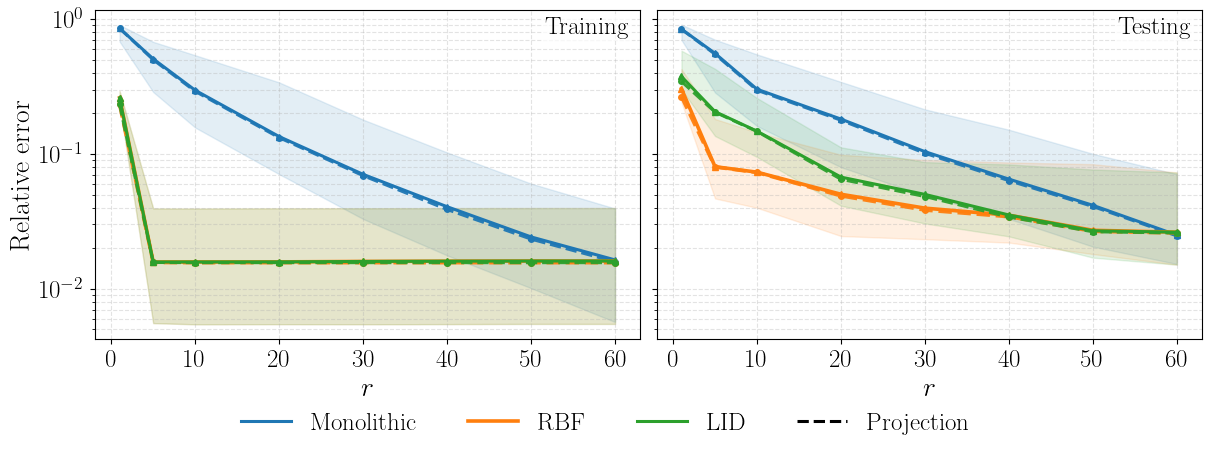

In [7]:
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
    "font.size": 18,
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

errs = np.load(os.path.join(savedir,"errors_60x60x60.npz"), allow_pickle=True)
r_arr = errs["r_arr"]

methods = ["mono", "rbf", "lid"]
colors = {"mono": "C0", "rbf": "C1", "lid": "C2"}
method_labels = {"mono": r"Monolithic", "rbf": r"RBF", "lid": r"LID"}

base_lw = 2.2
lw_method = {"mono": base_lw, "rbf": base_lw + 0.4, "lid": base_lw}

def plot_subplot(ax, title_text, key_fmt_rom, key_fmt_proj):
    for m in methods:
        # ROM: median + IQR band
        A = errs[key_fmt_rom.format(m=m)]
        med = np.median(A, axis=1)
        lo  = np.quantile(A, 0.25, axis=1)
        hi  = np.quantile(A, 0.75, axis=1)
        ax.plot(r_arr, med, color=colors[m], lw=lw_method[m], marker="^", ms=5)
        ax.fill_between(r_arr, lo, hi, color=colors[m], alpha=0.12)

        # Projection: median only (dashed)
        P = errs[key_fmt_proj.format(m=m)]
        pmed = np.median(P, axis=1)
        ax.plot(r_arr, pmed, color=colors[m], lw=lw_method[m], ls="--", marker="o", ms=4, alpha=0.95)

    ax.set_yscale("log")
    ax.grid(True, which="both", ls="--", alpha=0.35)

    # Title inside (top-right corner)
    ax.text(
        0.98, 0.98, title_text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=18,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2.0),
    )

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True, sharex=True, sharey=True)

plot_subplot(ax[0], r" Training", "{m}_rom_train", "{m}_proj_train")
plot_subplot(ax[1], r" Testing",  "{m}_rom_test",  "{m}_proj_test")


for a in ax:
    a.set_xlabel(r"$r$")

ax[0].set_ylabel(r"Relative error")

method_handles = [
    Line2D([0],[0], color=colors[m], lw=lw_method[m], label=method_labels[m]) for m in methods
]
style_handles = [
    #Line2D([0],[0], color="k", lw=2.2, ls="-",  label=r"ROM error"),
    Line2D([0],[0], color="k", lw=2.2, ls="--", label=r"Projection"),
]

fig.subplots_adjust(bottom=0.16)
fig.legend(method_handles + style_handles,
           [h.get_label() for h in (method_handles + style_handles)],
           loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.13))

plt.show()
